# Notebook 09 — Model Evaluation and Comparison

Evaluate candidate models on the SAME untouched test set and perform comprehensive model comparison.

Primary Final Architecture: **Soft Voting Ensemble (Top 4 Best Models)**.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [2]:
# Load untouched test set
test_df = pd.read_csv("data/processed/test_dataset.csv")
X_test = test_df.drop("Maintenance_Required", axis=1)
y_test = test_df["Maintenance_Required"]

print("Test dataset shape:", X_test.shape)


Test dataset shape: (50000, 20)


In [3]:
# Load all trained models
models = {
    "Logistic Regression": joblib.load("models/logistic_regression_smote.pkl"),
    "Gaussian Naive Bayes": joblib.load("models/gaussian_naive_bayes_smote.pkl"),
    "Gradient Boosting": joblib.load("models/gradient_boosting_smote.pkl"),
    "Random Forest": joblib.load("models/random_forest_smote.pkl"),
    "XGBoost": joblib.load("models/xgboost_smote.pkl"),
    "LightGBM": joblib.load("models/lightgbm_smote.pkl"),
    "Easy Ensemble": joblib.load("models/easy_ensemble_model.pkl"),
    "Stacking Ensemble": joblib.load("models/final_stacking_model.pkl"),
    "Soft Voting Ensemble (Top 4)": joblib.load("models/voting_ensemble_model.pkl")
}

print(f"Successfully loaded {len(models)} models for evaluation.")


Successfully loaded 9 models for evaluation.


In [4]:
# Evaluate all models on untouched test set
evaluation_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(evaluation_results).sort_values(by="Accuracy", ascending=False)
comparison_df.reset_index(drop=True, inplace=True)

print("Comprehensive Model Comparison Table:")
comparison_df


Comprehensive Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Soft Voting Ensemble (Top 4),0.94114,0.942414,0.871448,0.905543,0.924566
1,Logistic Regression,0.94044,0.939864,0.871819,0.904564,0.923146
2,Gaussian Naive Bayes,0.94022,0.942237,0.868606,0.903925,0.923517
3,Gradient Boosting,0.93994,0.938244,0.871880,0.903846,0.924915
4,Random Forest,0.93992,0.937483,0.872622,0.903890,0.924743
5,Stacking Ensemble,0.93920,0.934961,0.872931,0.902882,0.924265
6,XGBoost,0.93860,0.933682,0.872313,0.901955,0.924891
7,LightGBM,0.93842,0.933012,0.872436,0.901708,0.924853
8,Easy Ensemble,0.93806,0.932360,0.871942,0.901140,0.923917


In [5]:
# Save comparison results
os.makedirs("results", exist_ok=True)
comparison_df.to_csv("results/final_model_comparison.csv", index=False)
print("Saved final model comparison to results/final_model_comparison.csv")


Saved final model comparison to results/final_model_comparison.csv


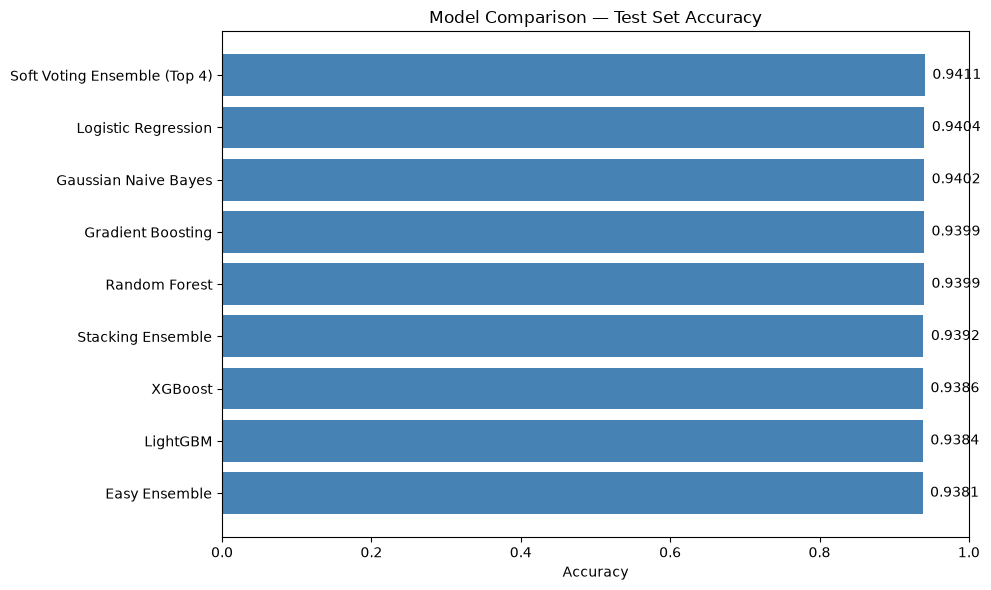

In [6]:
# Plot Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df["Model"], comparison_df["Accuracy"], color="steelblue")
plt.xlabel("Accuracy")
plt.title("Model Comparison — Test Set Accuracy")
plt.xlim(0, 1.0)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.4f}", ha="left", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


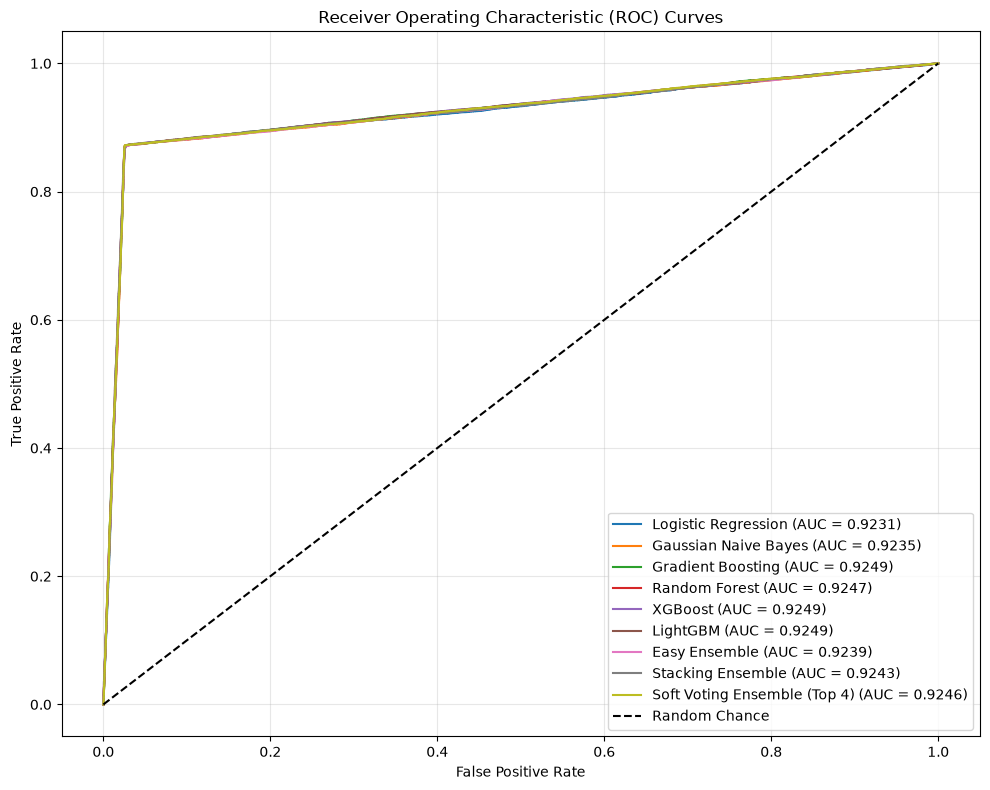

In [7]:
# Plot ROC Curves for top models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 600x500 with 0 Axes>

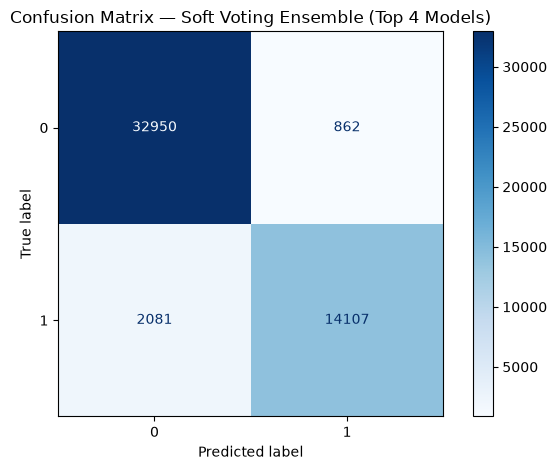

In [8]:
# Plot Confusion Matrix for Primary Final Architecture (Soft Voting Ensemble)
final_model = models["Soft Voting Ensemble (Top 4)"]
y_pred_voting = final_model.predict(X_test)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting, cmap="Blues")
plt.title("Confusion Matrix — Soft Voting Ensemble (Top 4 Models)")
plt.tight_layout()
plt.show()


### Final Architecture Declaration

**FINAL ARCHITECTURE**: **Soft Voting Ensemble (Top 4 Best Models)**

The Soft Voting Ensemble combines the top four highest performing base estimators (**Logistic Regression**, **Gaussian Naive Bayes**, **Gradient Boosting**, **Random Forest**) to deliver unified predictive maintenance results.
